# Lab session 1: Dimension reduction with Python

Dimension reduction is widely used in applied ML tasks for **visualization** as well as part of the pipeline for **scientific discovery**. In this lab, you will learn some standard methods for dimension reduction, and good practices in applied problems using manifold learning. 

In [ ]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import tqdm 
import pandas as pd
from scipy.spatial.distance import pdist, squareform


In [ ]:
from course_checks import grader

## Part 1. Deep dive on t-SNE and UMAP dimension reduction methods

For this exercise, we will use the baby MNIST dataset that you can load with `scikit-learn`. 

In [ ]:
# Run this cell to load the data
from sklearn.datasets import load_digits
data = load_digits()
X, y = data['data'], data['target']

fig, ax = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    ax[i].imshow(X[i,:].reshape(8,8))
    ax[i].set_title(f'Example digit {y[i]}')

### Question 0. Apply PCA to MNIST data
Apply PCA with `sklearn.decomposition`'s `PCA` in function in 2 dimensions. Plot the data on the embedding colored by true classes. Is it a satisfying embedding? What would be better? 

In [ ]:
# TODO: apply PCA function 
# TODO: plot the embedding colored by classes

In [ ]:
grader.check_embedding(X, Z)

## Question 1. A simplified t-SNE implementation 
What does t-SNE do? t-SNE maps the higher dimensional original data onto a lower dimensional embedding while preserving the pairwise similarities, $p_{ij}$ on the original space, $q_{ij}$ on the embedding space. 
* The original data's similarities are approximated with a normalized RBF kernel where the kernel width (perplexity hyperparameter) controls how "localized" the fitted kernel is - if $\sigma^2$ is large, then the kernel includes more neighbors, if small, it will tighten the kernel around each observation). 


$$
p_{j\mid i} =
\frac{\exp\left(-\lVert x_i-x_j\rVert^2/(2\sigma^2)\right)}
{\sum_{k\ne i}\exp\left(-\lVert x_i-x_k\rVert^2/(2\sigma^2)\right)},
\qquad p_{i\mid i}=0.
$$

After normalization and symmetrizing: $p_{ij}=\frac{p_{j\mid i}+p_{i\mid j}}{2n}.$


* The embedded data's similarity uses a Student-t kernel with 1 degree of freedom (essentially a Cauchy kernel) instead of RBF. This allows the embedding space to preserve distances of points **already close in original space**. 
$$
q_{ij}=
\frac{(1+\lVert z_i-z_j\rVert^2)^{-1}}
{\sum_{k\ne \ell}(1+\lVert z_k-z_\ell\rVert^2)^{-1}},
\qquad q_{ii}=0.
$$

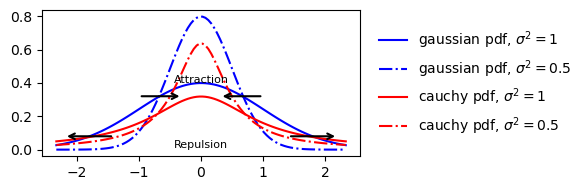


a) *Can we preserve all distances?* 

b) We are starting with computing the similarities in original dimension space and in embedding space.

In [ ]:
def original_similarities(X, sigma=1.0):
    # TODO: Compute RBF kernel for similarities 
    raise NotImplementedError("Complete original_similarities")

def embedding_similarities(Z):
    # TODO: Compute Cauchy kernel for similarities 
    raise NotImplementedError("Complete embedding_similarities")

In [ ]:
grader.check("lab1_original_similarities", original_similarities)
grader.check("lab1_embedding_similarities", embedding_similarities)

c) t-SNE optimizes the embedding where $Q$ lives on by minimising the KL divergence between $P$ and $Q$. Essentially, use gradient descent on
$$\min_{z} \text{KL}(P||Q) = \min_{z} \sum_{i,j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

*What are possible problems with this optimization problem?* 

d) Derive the gradient of the objective and use gradient descent to solve the optimization problem. 


In [ ]:
def compute_gradient(P, Q, Z): 
    # TODO: compute gradient
    raise NotImplementedError("Complete compute_gradient")

def gradient_descent(X, **kwargs):
    # TODO: implement gradient descent for the problem
    raise NotImplementedError("Complete gradient_descent")

In [ ]:
grader.check("lab1_compute_gradient", compute_gradient)

In [ ]:
grader.check("lab1_gradient_descent", gradient_descent)

d) Write up the `tsne` function by compiling all the steps. Apply it to the baby MNIST data. 


*Hints:*
-  *you might want to use a high learning rate 500 or more, the learning rate for t-SNE is usually in the range [10.0, 1000.0].*
-  *the initialized embedding points need to be sampled from a centered distribution with very small variance.*

In [ ]:
def tsne(X, **kwargs):
    # TODO: complete the function
    raise NotImplementedError("Complete tsne")

In [ ]:
# TODO: apply solution on MNIST and visualize the solution 

In [ ]:
grader.check_embedding(X, Z_hand)

## Question 2. Apply t-SNE out of the box
t-SNE is implemented in `sklearn.manifold`. Note that our version of `tsne` fixed the parameter `sigma`. The original `tsne` varies the bandwidth to match the required perplexity measure. Apply to obtain the 2D embedding and compare with your implementation.

In [ ]:
# TODO: Apply t-SNE out of the box to MNIST data
# TODO: Plot next to hand derived t-SNE. 

In [ ]:
grader.check_embedding(X, Z_tsne)

## Question 3. UMAP 

For this part, you will need to install the umap package: run in your environment the following command:
```{bash}
pip install umap-learn
```

UMAP is a technique similar to t-SNE in principle, but it focuses even further on local neighborhood:
1)  by adding a weighted k-nearest neighbor graph to the general distances: $p_{ij} \propto \exp\big(-\frac{1}{2\sigma^2}\sum_{i \in ne_k(j)} ||x_i-x_j||^2\big)$. 
2)  by using a generalized Cauchy kernel $q(z_i, z_j) = (1 + a||z_i-z_j||^{2b})^{-1}$ with $a > 1, b< 1$ which allows to control for thicker tails.


NameError: name 'norm' is not defined

Apply umap embedding to the baby MNIST data. Note that umap has the following hyperparameters: 
* `n_neighbors` used to compute the $k$-NN graph. 
* `min_dist` a parameter that controls the parameters $(a, b)$ from the generalized Cauchy distribution of the embedding points. 

a) Fit a 2-D UMAP using 5, 15, 50, 200 neighbors while holding everything else fixed, you can use the default `min_dist` value of 0.1. Visualize the results.

In [ ]:
!pip install umap-learn

In [ ]:
# TODO: plot the results of the embedding with the 4 values of n_neighbors

In [ ]:
grader.check_embedding(X, Z_umap)

b) Fit a 2-D UMAP using `min_dist` with values 0, 0.1, 0.5 and 0.8 while holding `n_neighbors=20`. Visualize the results.

In [ ]:
# TODO: plot the results of the embedding with the 4 values of min_dist

In [ ]:
grader.check_embedding(X, Z_umap)

c) What do you observe? What are the challenges of dimension reduction for visualization? 

## Bonus question:
If you've finished the previous parts early, you can work towards implementing the full t-SNE routine. The perplexity in the t-SNE paper is defined as $$\text{per} = 2^{H} \text{ where } H = - \sum_{ij} p_{ij} \log p_{ij}$$

1) Replace the fixed bandwidth with a binary search for observation-specific bandwidths that match a target perplexity.
2) The implementation adds *momentum* to the gradient descent. The momentum term is added to the gradient to speed up optimization and avoid local minima. Mathematically: 

$$z^{(t)} = z^{(t-1)} + \eta \frac{\partial C}{\partial z} + \underbrace{\textcolor{red}{\alpha(t) \big( z^{(t-1)}-z^{(t-2)}\big)}}_{\text{momentum } \alpha(t)}$$


# Part 2. Good practices of dimension reduction

### Question 4. Dimension reduction for data visualization

Get the additional embeddings of the usual manifold learning methods (under `sklearn.manifold`): ISOMAP, LLE, Spectral Embedding, tSNE. What are the hyperparameters for each method? Get a 2 by 5 panel showing each method + UMAP with at least 2 values of one of the main hyperparameters colored by their classes when possible. 

In [ ]:
# TODO: explore more traditional manifold embedding methods

In [ ]:
for Z_check in embeddings.values():
    grader.check_embedding(X, Z_check)

What makes a better embedding? 

### Question 5. Comparing dimension reduction methods

Does an embedding method better preserve **local neighborhoods** or **global distances**? Define the original data distances $d_{ij} = ||X_i - X_j||_2$ and the embedding distances $\delta_{ij} = ||z_i - z_j||_2$ where $z_i = f(X_i)$ the embedded data point.  Construct the following two metrics: 
1) `global_distance_preservation`: the correlation between high-dimensional and two-dimensional pairwise distances.
Let $D = (d_{ij})$ and $\Delta=(\delta_{ij})$, the global preservation score of the dataset is:
$$\rho(D, \Delta) = \frac{Cov(D, \Delta)}{\sqrt{Var(D)Var(\Delta)}}$$
2) `local_neighborhood_preservation`: the fraction of $k$-nearest neighbors preserved where for any observation $i$, 
$$p_{k}(i) = \frac{|\{j \in ne_{k}(X_{i}) \} \cap \{ j \in ne_{k}(z_{i}) \} |}{k}.$$
And the local neighborhood score is:
$$p_k = \frac{1}{n} \sum_i p_k(i)$$
 


In [ ]:
def global_distance_preservation(X, Z):
    # TODO: take X and Z, compute pairwise distances respetively to get D and \Delta 
    # to compute \rho(d_{ij}, \delta_{ij}) across all observations pairs (i,j)
    # note that this measure is symmetric in (i,j )
    raise NotImplementedError("Complete global_distance_preservation")

def local_neighborhood_preservation(X, Z, k=10):
    # TODO: take X, Z get respective nearest k-neighbors to compute p_k
    raise NotImplementedError("Complete local_neighborhood_preservation")

In [ ]:
grader.check("lab1_global_preservation", global_distance_preservation)
grader.check("lab1_local_preservation", local_neighborhood_preservation)

Take embeddings obtained in **Question 4** and compute the new preservation metrics for each embedding method, and both hyperparameter values. Plot the 11 points in a scatter plot with local neighborhood preservation as the y axis and global preservation as the x axis. For local neighborhood preservation, you can set $k=10$. Add the metrics for PCA.

In [ ]:
# TODO: get metrics for all 5 methods, 2 hyperparameter values

# TODO: scatter plot of 11 points along the two axes: global and local preservation

### Question 6. How do we choose the hyperparameters? 

We'll explore hyperparameter tuning for the `LocalLinearEmbedding` method. For starters, let's consider the neighbor grid values $k \in \{5, 15, 25, 50, 100\}$.
1) Validation via supervised downstream tasks in the presence of labels.
Apply LLE to get the manifold embedding $Z$ for each value of the neighbor hyperparameter. Use a classifier of your choice and two classification metrics to evaluate classifying the digit labels using the manifold. For each metric, plot out the classification metric against neighbor grid.  

In [ ]:
# TODO: Using classification to evaluate hyperparameters

2. Validation via stability principle. 

One alternative option is to choose the hyperparameters that results to the most stable neighborhoods. This is typically more computationally expensive, you will investigate the following two ways to validate stability, by subsampling the data and by adding random noise. 


a) Random noise perturbation 
* Generate standard Gaussian noise to add to the data.
* Refit manifold embedding on the perturbed data.
* Compute local-preservation metric. 
* Plot the local preservation metric (with default $k=20$) against neighbor grid values.

In [ ]:
# TODO: Random noise perturbation validation

b) Data subsampling
* Subsample the data 10 times, use 30% of the data on each.
* Fit the manifold embedding on each subsample.
* Compute local-preservation metric. Aggregate the metric to get average local preservation + SE.
* Plot the local preservation metric (with default $k=20$) against neighbor grid values.

In [ ]:
# TODO: Data subsampling fro validation

3. Propose a way to tune the hyperparameter based on some neighborhood preservation metric inspired by earlier metrics.

In [ ]:
# TODO: Propose a tuning scheme 

4. Conclude

# Part III. Application on dataset 


### Question 7. Visualizing data 
On a dataset of your choosing, apply at least two non linear dimension reduction methods to visualize the data. You can use any relevant dataset from the [**UCI repository**](https://archive.ics.uci.edu/) or the *literary_styles_dataset.csv* under the `data/` folder. Make sure that you have at least 20 features in the data and that it is **not** a binary classification task.
Suggested steps: 
1) First, prepare the data appropriately (normalization, scaling etc. if needed). 
2) Observe the PCA embedding for 2 components. 
3) Choose the DR methods based on your assessment of the PCA embedding. 
4) Tune for hyperparameters of your methods. 


In [ ]:
!pip install ucimlrepo #run this if you use a ucimlrepo dataset

In [ ]:
# TODO: load dataset and process it. 

In [ ]:
# TODO: Dimension reduction analysis. 

What motivated the choice of method of dimension reduction? Are the visualizations more useful for local neighborhood preservation or global preservation? Does that align with your intuition on the data? 

### Question 8. Scientific discovery with manifold learning

What do you takeaway from the previous visualizations? What would you caution a scientist against while interpreting the embeddings? 